# Modelo de Machine Learning - Predicción de Precios
## Dataset: Properatti
**Objetivo:** Entrenar y evaluar modelos de regresión para predecir el precio de propiedades en Argentina.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cargar dataset con feature engineering
df = pd.read_csv('properatti_fe.csv')

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 67072
Columnas: 34


,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,precio_promedio_zona,precio_promedio_tipo,ratio_superficie,property_type_PH,property_type_apartment,property_type_house,property_type_store,...,state_name_Misiones,state_name_Neuquén,state_name_Río Negro,state_name_Salta,state_name_San Luis,state_name_Santa Cruz,state_name_Santa Fe,state_name_Santiago Del Estero,state_name_Tierra Del Fuego,state_name_Tucumán
0,62000.0,55.0,40.0,179231.982107,138967.880813,0.727273,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,150000.0,80.0,72.0,168665.827623,151935.533469,0.900000,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,72000.0,55.0,55.0,179231.982107,151935.533469,1.000000,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,95000.0,80.0,72.0,179231.982107,138967.880813,0.900000,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,64000.0,35.0,35.0,133634.905788,151935.533469,1.000000,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


### 1. Separación de variables y split de datos

In [2]:
# Separar variable objetivo (Y) de variables predictoras (X)
X = df.drop(columns=['price_aprox_usd'])
y = df['price_aprox_usd']

print(f"Variables predictoras (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDatos de entrenamiento: {X_train.shape[0]} filas")
print(f"Datos de prueba: {X_test.shape[0]} filas")

Variables predictoras (X): (67072, 33)
Variable objetivo (y): (67072,)

Datos de entrenamiento: 53657 filas
Datos de prueba: 13415 filas


### 2. Entrenamiento y evaluación de modelos

In [3]:
# Función para evaluar modelos
def evaluar_modelo(nombre, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"--- {nombre} ---")
    print(f"MAE:  USD {mae:,.0f}")
    print(f"RMSE: USD {rmse:,.0f}")
    print(f"R²:   {r2:.4f}")
    print()

# Modelo 1: Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluar_modelo("Regresión Lineal", y_test, y_pred_lr)

# Modelo 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

--- Regresión Lineal ---
MAE:  USD 61,519
RMSE: USD 83,376
R²:   0.4219

--- Random Forest ---
MAE:  USD 45,153
RMSE: USD 67,634
R²:   0.6196



In [7]:
from xgboost import XGBRegressor

# Modelo 3: XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
evaluar_modelo("XGBoost", y_test, y_pred_xgb)

--- XGBoost ---
MAE:  USD 45,526
RMSE: USD 66,222
R²:   0.6353



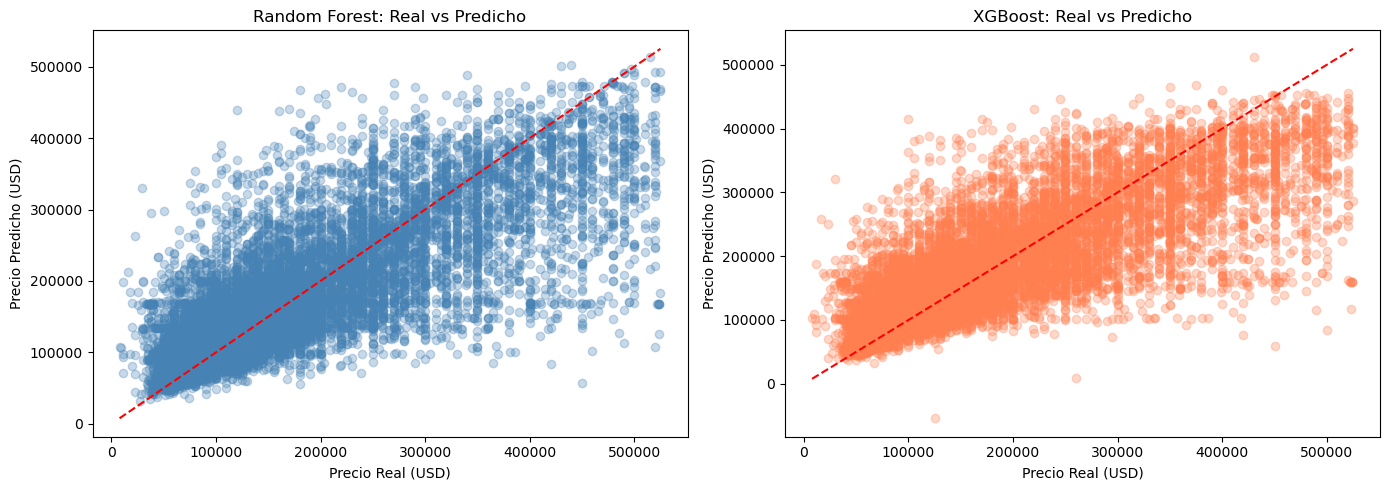

In [8]:
# Visualización: predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Random Forest: Real vs Predicho')
axes[0].set_xlabel('Precio Real (USD)')
axes[0].set_ylabel('Precio Predicho (USD)')

# XGBoost
axes[1].scatter(y_test, y_pred_xgb, alpha=0.3, color='coral')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('XGBoost: Real vs Predicho')
axes[1].set_xlabel('Precio Real (USD)')
axes[1].set_ylabel('Precio Predicho (USD)')

plt.tight_layout()
plt.show()

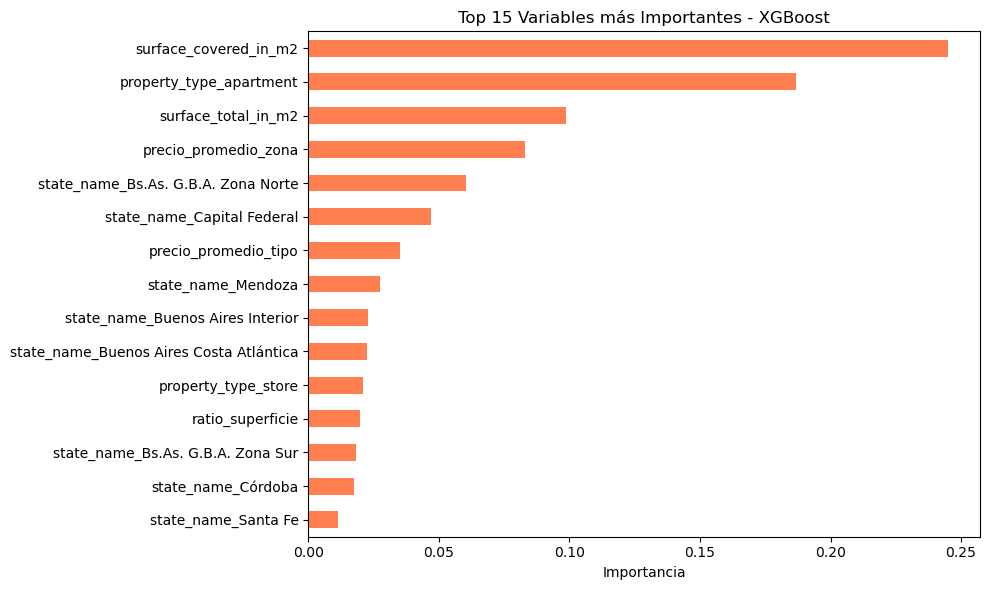

In [9]:
# Importancia de variables - XGBoost
importancias = pd.Series(xgb.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='coral')
plt.title('Top 15 Variables más Importantes - XGBoost')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()